# 01 — Data Processing

**What it does:**
1. Loads the 3 raw CSV files (PV, weather station, weather forecast)
2. Cleans and renames columns
3. Auto-picks the best PV array (most valid data)
4. Converts power from Watts → kWh
5. Merges PV + weather into one table
6. Does some quick EDA plots
7. Saves the result as `data/dataset.csv`
8. Reference taken from : https://github.com/unizg-fer-lares/dataset-pv/blob/main/python/data_analysis/data_processing.py
9. Basically converted .py file into .ipynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

print('Libraries loaded ✓')

Libraries loaded ✓


In [17]:
from pathlib import Path
import matplotlib.pyplot as plt

FIG_DIR = Path("../figure")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load the 3 raw CSV files

In [2]:
pv_path       = '../data/photovoltaic_measurement_history.csv'
weather_path  = '../data/weather_station_measurement_history.csv'
forecast_path = '../data/weather_prediction_history.csv'

pv = pd.read_csv(
    pv_path,
    index_col='photovoltaic_measurement_timestamp',
    parse_dates=['photovoltaic_measurement_timestamp'],
)

weather = pd.read_csv(
    weather_path,
    index_col='weather_station_measurement_timestamp',
    parse_dates=['weather_station_measurement_timestamp'],
)

weather_for = pd.read_csv(
    forecast_path,
    index_col='weather_prediction_timestamp',
    parse_dates=['weather_prediction_timestamp'],
)

print('Raw shapes:')
print(f'  pv              : {pv.shape}')
print(f'  weather         : {weather.shape}')
print(f'  weather_forecast: {weather_for.shape}')

Raw shapes:
  pv              : (8716548, 8)
  weather         : (2204759, 17)
  weather_forecast: (9019, 25)


## 2. Drop unused columns and rename

In [3]:
pv = pv.drop(columns=[
    'id',
    'batch_timestamp',
    'photovoltaic_measurement_reactive_power',
])
pv.columns = ['id', 'power', 'pv_global_irradiance', 'T1', 'T2']
pv.index.name = 'timestamp'

print('PV columns:', pv.columns.tolist())
pv.head(3)

PV columns: ['id', 'power', 'pv_global_irradiance', 'T1', 'T2']


,id,power,pv_global_irradiance,T1,T2
timestamp,,,,,
2018-04-17 05:24:00,3,5.0,5.0,11.3,10.6
2018-04-17 05:24:00,1,3.0,3.0,11.2,10.7
2018-04-17 05:24:00,2,1.0,3.0,11.7,11.1


In [4]:
weather = weather.drop(columns=[
    'id',
    'batch_timestamp',
    'weather_station_id',
    'weather_station_measurement_outdoor_temperature_north',
    'weather_station_measurement_global_irradiance_estimated',
    'weather_station_measurement_irradiance_estimation_error',
    'weather_station_measurement_reflected_solar_irradiance',
    'weather_station_measurement_wind_speed',
    'weather_station_measurement_wind_direction',
    'weather_station_measurement_relative_humidity',
    'weather_station_measurement_pressure_at_xy_meters',
])
weather.columns = [
    'sun_zenith', 'sun_azimuth', 'temperature',
    'global_irradiance', 'direct_irradiance', 'diffuse_irradiance',
]
weather.index.name = 'timestamp'

print('Weather columns:', weather.columns.tolist())
weather.head(3)

Weather columns: ['sun_zenith', 'sun_azimuth', 'temperature', 'global_irradiance', 'direct_irradiance', 'diffuse_irradiance']


,sun_zenith,sun_azimuth,temperature,global_irradiance,direct_irradiance,diffuse_irradiance
timestamp,,,,,,
2018-04-17 05:24:00,77.63,-92.47,14.1,7,-1,7
2018-04-17 05:25:00,77.46,-92.29,14.1,8,-1,8
2018-04-17 05:26:00,77.28,-92.12,14.1,8,-1,8


In [5]:
weather_for = weather_for.drop(columns=[
    'id',
    'weather_predictor_id',
    'weather_prediction_dew_point_at_2m',
    'weather_prediction_relative_humidity_at_2m',
    'weather_prediction_mean_wind_speed_at_10m',
    'weather_prediction_wind_direction_at_10m',
    'weather_prediction_wind_gust_at_10m',
    'weather_prediction_mean_wind_speed_at_bldg_top',
    'weather_prediction_wind_direction_at_bldg_top',
    'weather_prediction_mean_sea_level_pressure',
    'weather_prediction_total_cloud_coverage',
    'weather_prediction_high_cloud_coverage',
    'weather_prediction_low_cloud_coverage',
    'weather_prediction_mean_cloud_coverage',
    'weather_prediction_total_precipitation',
    'weather_prediction_total_snow',
    'weather_prediction_variance_of_the_2m_temperature',
    'weather_prediction_variance_of_direct_solar_irradiance',
    'weather_prediction_variance_of_diffuse_solar_irradiance',
    'weather_prediction_variance_of_total_irradiance',
])
weather_for.columns = [
    'start_timestamp_for', 'temperature_for',
    'direct_irradiance_for', 'diffuse_irradiance_for', 'global_irradiance_for',
]
weather_for.index.name = 'timestamp'

print('Forecast columns:', weather_for.columns.tolist())

Forecast columns: ['start_timestamp_for', 'temperature_for', 'direct_irradiance_for', 'diffuse_irradiance_for', 'global_irradiance_for']


## 3. Pick the best PV array (auto)

There are 7 PV arrays (IDs 1–7). We pick the one with the **most valid (non-missing) power readings**.

In [6]:
print(f'Unique PV IDs: {sorted(pv["id"].unique())}')
print(f'Total rows   : {len(pv)}')


pv_overview = pd.DataFrame(index=sorted(pv['id'].unique()),
                            columns=['n_rows', 'missing_power', 'missing_pct'])

for pv_id in pv_overview.index:
    s = pv.loc[pv['id'] == pv_id, 'power']
    pv_overview.loc[pv_id, 'n_rows']        = len(s)
    pv_overview.loc[pv_id, 'missing_power'] = int(s.isna().sum())
    pv_overview.loc[pv_id, 'missing_pct']   = round(100 * s.isna().mean(), 2)

pv_overview['valid'] = pv_overview['n_rows'].astype(int) - pv_overview['missing_power'].astype(int)
pv_overview = pv_overview.sort_values('valid', ascending=False)
print('\nPer-ID overview:')
print(pv_overview)


best_pv_id = int(pv_overview['valid'].idxmax())
print(f'\n→ Selected PV ID: {best_pv_id}')

Unique PV IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Total rows   : 8716548

Per-ID overview:
    n_rows missing_power missing_pct    valid
1  1245225         40062        3.22  1205163
3  1245220         40062        3.22  1205158
2  1245219         40062        3.22  1205157
5  1245220        215160       17.28  1030060
4  1245220        248074       19.92   997146
6  1245221        588751       47.28   656470
7  1245223       1245223       100.0        0

→ Selected PV ID: 1


In [7]:
pv_sel = pv[pv['id'] == best_pv_id].copy()


pv_sel = pv_sel[~pv_sel.index.duplicated(keep='first')]


pv_sel = pv_sel.dropna(how='any')

print(f'PV rows after cleaning: {len(pv_sel)}')
print(f'Date range: {pv_sel.index.min()} → {pv_sel.index.max()}')

PV rows after cleaning: 1205163
Date range: 2018-04-17 05:24:00 → 2020-12-19 08:50:00


## 4. Convert power: Watts → kWh

Raw data = instantaneous power in **Watts**, measured every minute.

Dividing by 1000 (W→kW) and by 60 (1 minute → 1 hour) gives the **energy in kWh** for that 1-minute sample.

Later when we resample to 15min by summing, each row becomes total kWh in that 15-min window.

In [8]:
pv_sel['power'] = pv_sel['power'] / 1000.0 / 60.0


pv_sel = pv_sel[['power']]

print('Power unit: kWh (per 1-min sample)')
print(pv_sel.describe())

Power unit: kWh (per 1-min sample)
              power
count  1.205163e+06
mean   7.797865e-03
std    1.387460e-02
min    0.000000e+00
25%    0.000000e+00
50%    0.000000e+00
75%    8.333333e-03
max    6.026667e-02


## 5. Clean weather data

In [9]:
irr_cols = [c for c in weather.columns if 'irradiance' in c]
weather[irr_cols] = weather[irr_cols].clip(lower=0)

print('Weather irradiance columns clipped to 0 ✓')
print(weather.describe())

Weather irradiance columns clipped to 0 ✓
         sun_zenith   sun_azimuth   temperature  global_irradiance  \
count  2.204759e+06  2.204759e+06  2.204759e+06       2.204759e+06   
mean   8.920557e+01 -1.967075e-01  1.407425e+01       1.546366e+02   
std    3.311091e+01  1.015234e+02  8.638944e+00       2.496639e+02   
min    2.239000e+01 -1.798700e+02 -6.200000e+00       0.000000e+00   
25%    6.417000e+01 -9.043000e+01  7.200000e+00       0.000000e+00   
50%    8.925000e+01 -6.000000e-01  1.360000e+01       0.000000e+00   
75%    1.139600e+02  9.020000e+01  2.060000e+01       2.200000e+02   
max    1.576200e+02  1.798800e+02  4.080000e+01       1.350000e+03   

       direct_irradiance  diffuse_irradiance  
count       2.204759e+06        2.204759e+06  
mean        1.497542e+02        6.364601e+01  
std         2.711536e+02        9.854202e+01  
min         0.000000e+00        0.000000e+00  
25%         0.000000e+00        0.000000e+00  
50%         0.000000e+00        1.000000e+00 

## 6. Merge PV + Weather

In [10]:
# Outer join on timestamp index
# outer = keep all timestamps from both tables (fill gaps with NaN)
dataset = pd.merge(pv_sel, weather, left_index=True, right_index=True, how='outer')
dataset.index.name = 'timestamp'

print(f'Merged dataset shape: {dataset.shape}')
print(f'Columns: {dataset.columns.tolist()}')
print(f'Date range: {dataset.index.min()} → {dataset.index.max()}')
dataset.head()

Merged dataset shape: (2204759, 7)
Columns: ['power', 'sun_zenith', 'sun_azimuth', 'temperature', 'global_irradiance', 'direct_irradiance', 'diffuse_irradiance']
Date range: 2018-04-17 05:24:00 → 2023-03-04 22:54:00


,power,sun_zenith,sun_azimuth,temperature,global_irradiance,direct_irradiance,diffuse_irradiance
timestamp,,,,,,,
2018-04-17 05:24:00,0.000050,77.63,-92.47,14.1,7,0,7
2018-04-17 05:25:00,0.000050,77.46,-92.29,14.1,8,0,8
2018-04-17 05:26:00,0.000050,77.28,-92.12,14.1,8,0,8
2018-04-17 05:27:00,0.000050,77.11,-91.94,14.1,9,0,9
2018-04-17 05:28:00,0.000067,76.93,-91.76,14.1,10,0,10


## 7. EDA Plots

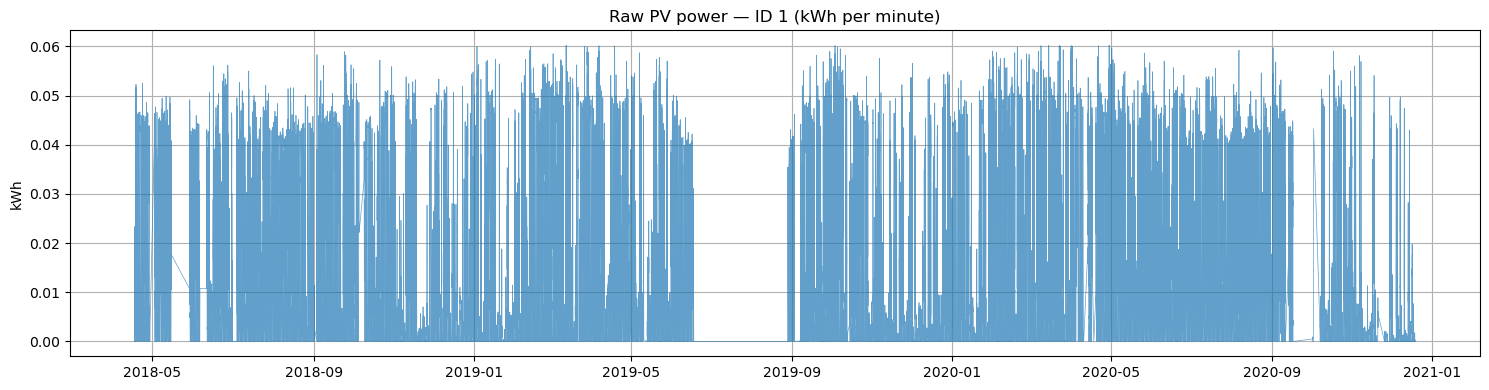

In [18]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(pv_sel['power'], linewidth=0.5, alpha=0.7)
ax.set_title(f'Raw PV power — ID {best_pv_id} (kWh per minute)')
ax.set_ylabel('kWh')
ax.grid(True)
plt.tight_layout()
fig.savefig(FIG_DIR / "raw_pv_power.png", dpi=300, bbox_inches="tight")
plt.show()

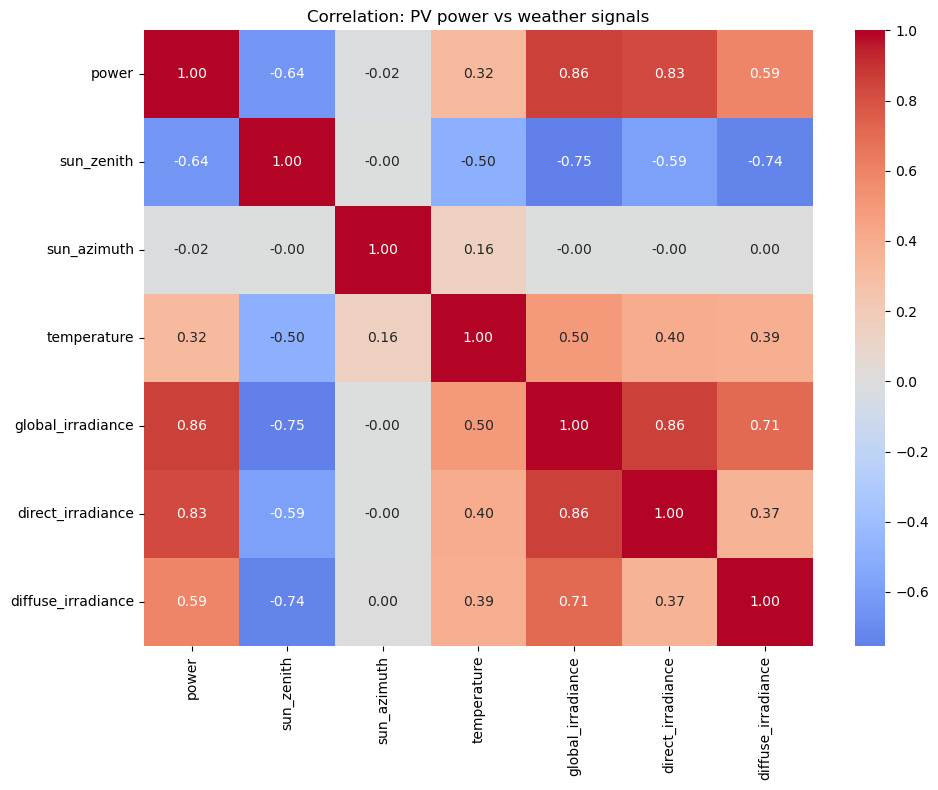

In [19]:
plt.figure(figsize=(10, 8))
corr = dataset.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: PV power vs weather signals')
plt.tight_layout()
plt.savefig(
    FIG_DIR / "Fig02_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

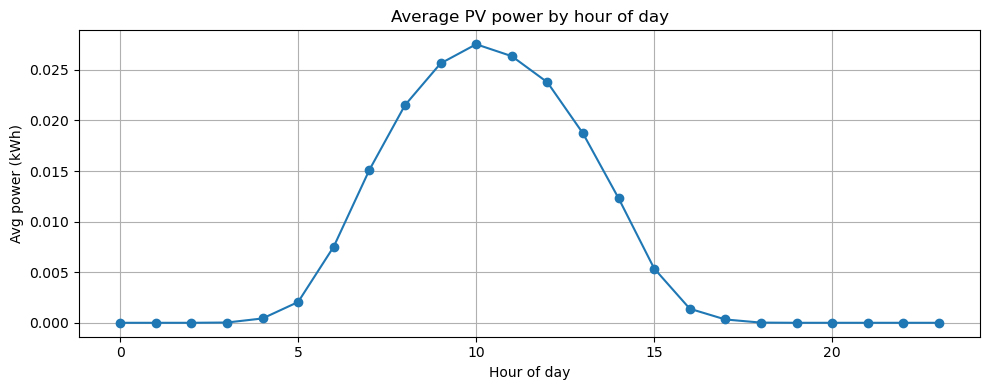

In [20]:
hourly = dataset['power'].dropna().groupby(dataset['power'].dropna().index.hour).mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly.plot(ax=ax, marker='o')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg power (kWh)')
ax.set_title('Average PV power by hour of day')
ax.grid(True)
plt.tight_layout()
fig.savefig(
    FIG_DIR / "Fig03_average_power_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

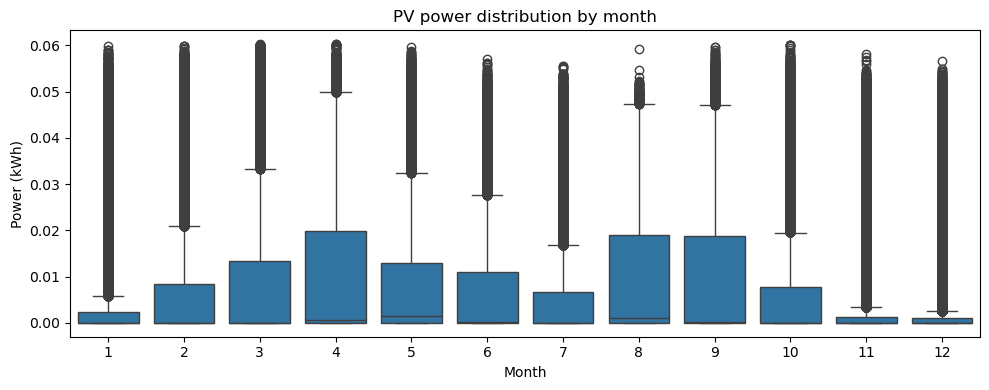

In [21]:
df_plot = dataset[['power']].dropna().copy()
df_plot['month'] = df_plot.index.month

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df_plot, x='month', y='power', ax=ax)
ax.set_title('PV power distribution by month')
ax.set_xlabel('Month')
ax.set_ylabel('Power (kWh)')
plt.tight_layout()
fig.savefig(
    FIG_DIR / "Fig04_monthly_power_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

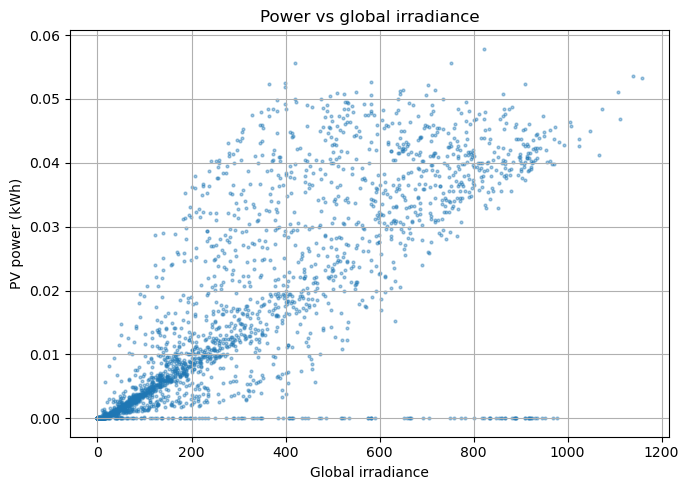

In [22]:
sample = dataset[['power', 'global_irradiance']].dropna().sample(
    min(5000, len(dataset)), random_state=0
)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample['global_irradiance'], sample['power'], s=4, alpha=0.4)
ax.set_xlabel('Global irradiance')
ax.set_ylabel('PV power (kWh)')
ax.set_title('Power vs global irradiance')
ax.grid(True)
plt.tight_layout()
fig.savefig(
    FIG_DIR / "Fig05_power_vs_global_irradiance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 8. Save dataset.csv

In [16]:
output_path = '../data/dataset.csv'
dataset.to_csv(output_path)

print(f'Saved → {output_path}')
print(f'Shape : {dataset.shape}')
print(f'Range : {dataset.index.min()} → {dataset.index.max()}')
print('\n✓ Now run 02_baseline_forecasting.ipynb')

Saved → ../data/dataset.csv
Shape : (2204759, 7)
Range : 2018-04-17 05:24:00 → 2023-03-04 22:54:00

✓ Now run 02_baseline_forecasting.ipynb
